In [1]:
log_path = 'training_log.txt'

In [2]:
# imports

import re
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pattern = re.compile(
    r'^(?P<epoch>\d+),(?P<loss>[^,]+),(?P<improvement>[^,]+),\[(?P<diversity>[^\]]+)\],\[(?P<pixel_diff>[^\]]+)\],\[(?P<ssim>[^\]]+)\],(?P<time_min>[^,\n]+)$'
)

labels = ['A', 'B', 'G']
metrics = ['ssim', 'diversity', 'pixel_diff']

rows = []
with open(log_path) as f:
    for line in f:
        line = line.strip()

         # skip header
        if not line or line.startswith('epoch'):
            continue
        m = pattern.match(line)

        if not m:
            continue
        def to_list(s):
            return [float(x.strip()) for x in s.split(',') if x.strip()]
        
        div = to_list(m.group('diversity'))
        pix = to_list(m.group('pixel_diff'))
        ssm = to_list(m.group('ssim'))
        if not (len(div) == len(pix) == len(ssm) == 3):
            continue
        rows.append({
            'epoch': int(m.group('epoch')),
            'diversity_A': div[0], 'diversity_B': div[1], 'diversity_G': div[2],
            'pixel_diff_A': pix[0], 'pixel_diff_B': pix[1], 'pixel_diff_G': pix[2],
            'ssim_A': ssm[0], 'ssim_B': ssm[1], 'ssim_G': ssm[2],
        })

df = pd.DataFrame(rows).sort_values('epoch').reset_index(drop=True)
df.tail(3)

,epoch,diversity_A,diversity_B,diversity_G,pixel_diff_A,pixel_diff_B,pixel_diff_G,ssim_A,ssim_B,ssim_G
17,18,0.0063,0.0107,0.0157,0.0109,0.0147,0.0191,0.7993,0.8263,0.7778
18,19,0.0095,0.0123,0.0180,0.0112,0.0158,0.0204,0.8318,0.8147,0.7741
19,20,0.0089,0.0106,0.0164,0.0115,0.0145,0.0202,0.8292,0.8180,0.7997


In [4]:
# ensure dataframe is in the correct shape

df.shape[0] == 60

False

### Diversity Score Over Ecpochs

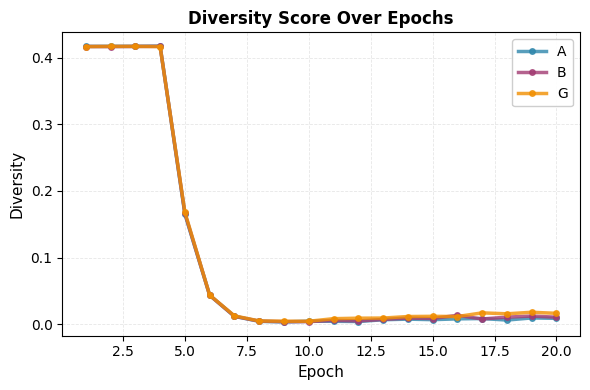

In [5]:
# plot the observations of diversity score

colors = {'A': '#2E86AB', 'B': '#A23B72', 'G': '#F18F01'}

plt.figure(figsize=(6,4))
for lab in labels:
    plt.plot(df['epoch'], df[f'diversity_{lab}'], label=lab, linewidth=2.5, 
             color=colors[lab], marker='o', markersize=4, alpha=0.8)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Diversity', fontsize=11)
plt.title('Diversity Score Over Epochs', fontsize=12, fontweight='bold')
plt.legend(framealpha=0.95, fontsize=10)
plt.grid(linestyle='--', linewidth=0.6, alpha=0.3)
plt.tight_layout()
plt.show()

### Pixel-level Difference Over Epochs

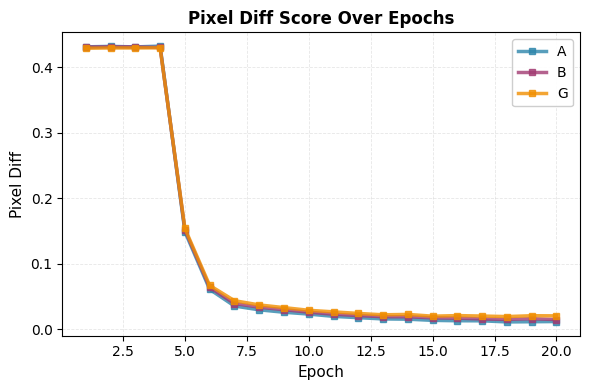

In [6]:
# plot the observations of pixel level difference

colors = {'A': '#2E86AB', 'B': '#A23B72', 'G': '#F18F01'}

plt.figure(figsize=(6,4))
for lab in labels:
    plt.plot(df['epoch'], df[f'pixel_diff_{lab}'], label=lab, linewidth=2.5,
             color=colors[lab], marker='s', markersize=4, alpha=0.8)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Pixel Diff', fontsize=11)
plt.title('Pixel Diff Score Over Epochs', fontsize=12, fontweight='bold')
plt.legend(framealpha=0.95, fontsize=10)
plt.grid(linestyle='--', linewidth=0.6, alpha=0.3)
plt.tight_layout()
plt.show()

### SSIM Score Over Epochs

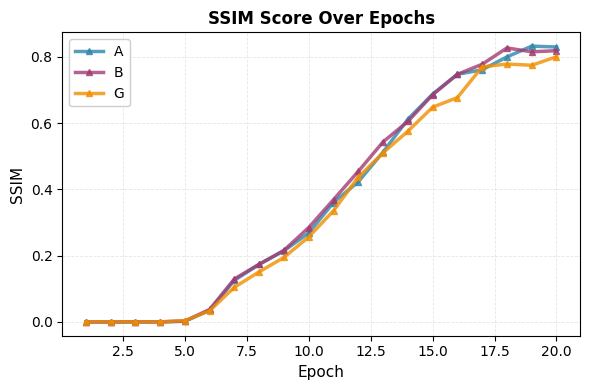

In [7]:
# plot the observations of SSIM score

colors = {'A': '#2E86AB', 'B': '#A23B72', 'G': '#F18F01'}

plt.figure(figsize=(6,4))
for lab in labels:
    plt.plot(df['epoch'], df[f'ssim_{lab}'], label=lab, linewidth=2.5,
             color=colors[lab], marker='^', markersize=4, alpha=0.8)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('SSIM', fontsize=11)
plt.title('SSIM Score Over Epochs', fontsize=12, fontweight='bold')
plt.legend(framealpha=0.95, fontsize=10)
plt.grid(linestyle='--', linewidth=0.6, alpha=0.3)
plt.tight_layout()
plt.show()

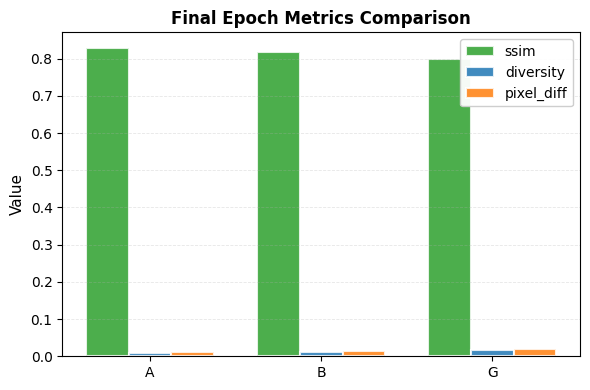

In [8]:
# final epoch comparison

import numpy as np
final = df.iloc[-1]
bar_labels = labels
x = np.arange(len(bar_labels))
width = 0.25

metric_colors = {'diversity': '#1f77b4', 'pixel_diff': '#ff7f0e', 'ssim': '#2ca02c'}

fig, ax = plt.subplots(figsize=(6,4))
for i, metric in enumerate(metrics):
    ax.bar(x + (i-1)*width, [final[f'{metric}_{lab}'] for lab in bar_labels], 
           width, label=metric, color=metric_colors[metric], alpha=0.85, edgecolor='white', linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(bar_labels, fontsize=10)
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Final Epoch Metrics Comparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.95)
ax.grid(linestyle='--', linewidth=0.6, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

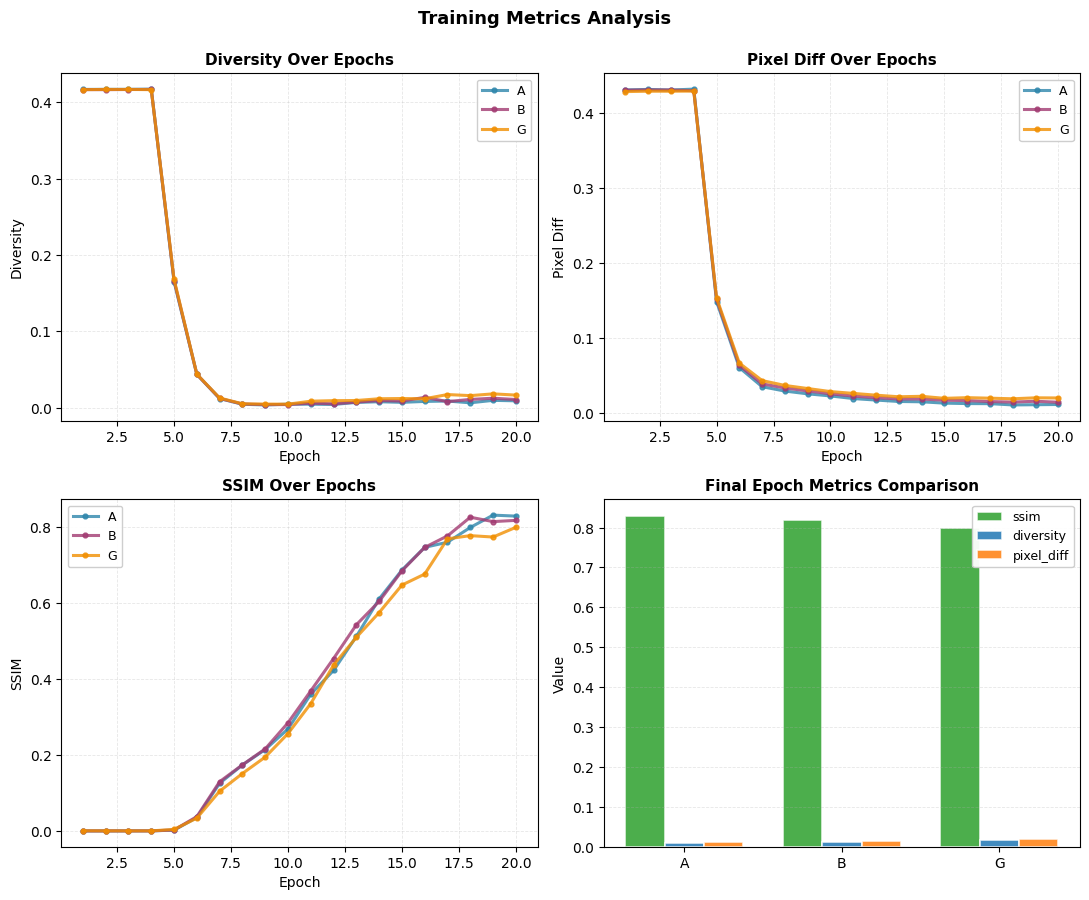

In [9]:
colors = {'A': '#2E86AB', 'B': '#A23B72', 'G': '#F18F01'}
metric_colors = {'diversity': '#1f77b4', 'pixel_diff': '#ff7f0e', 'ssim': '#2ca02c'}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
(ax_div, ax_pix), (ax_ssim, ax_bar) = axes

# helper to plot a line chart for a metric across epochs for all classes
def plot_metric_lines(ax, metric_key, title, ylabel):
    for lab in labels:
        ax.plot(df['epoch'], df[f'{metric_key}_{lab}'], label=lab, linewidth=2.2,
                color=colors[lab], marker='o', markersize=3.5, alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(linestyle='--', linewidth=0.6, alpha=0.3)
    ax.legend(fontsize=9, framealpha=0.95)

plot_metric_lines(ax_div, 'diversity', 'Diversity Over Epochs', 'Diversity')
plot_metric_lines(ax_pix, 'pixel_diff', 'Pixel Diff Over Epochs', 'Pixel Diff')
plot_metric_lines(ax_ssim, 'ssim', 'SSIM Over Epochs', 'SSIM')

final = df.iloc[-1]
bar_labels = labels
x = np.arange(len(bar_labels))
width = 0.25
for i, metric in enumerate(metrics):
    ax_bar.bar(
        x + (i-1)*width,
        [final[f'{metric}_{lab}'] for lab in bar_labels],
        width,
        label=metric,
        color=metric_colors[metric],
        alpha=0.85,
        edgecolor='white',
        linewidth=1.2
    )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(bar_labels, fontsize=10)
ax_bar.set_ylabel('Value', fontsize=10)
ax_bar.set_title('Final Epoch Metrics Comparison', fontsize=11, fontweight='bold')
ax_bar.legend(fontsize=9, framealpha=0.95)
ax_bar.grid(linestyle='--', linewidth=0.6, alpha=0.3, axis='y')
fig.suptitle('Training Metrics Analysis', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Rsults of Final Epoch

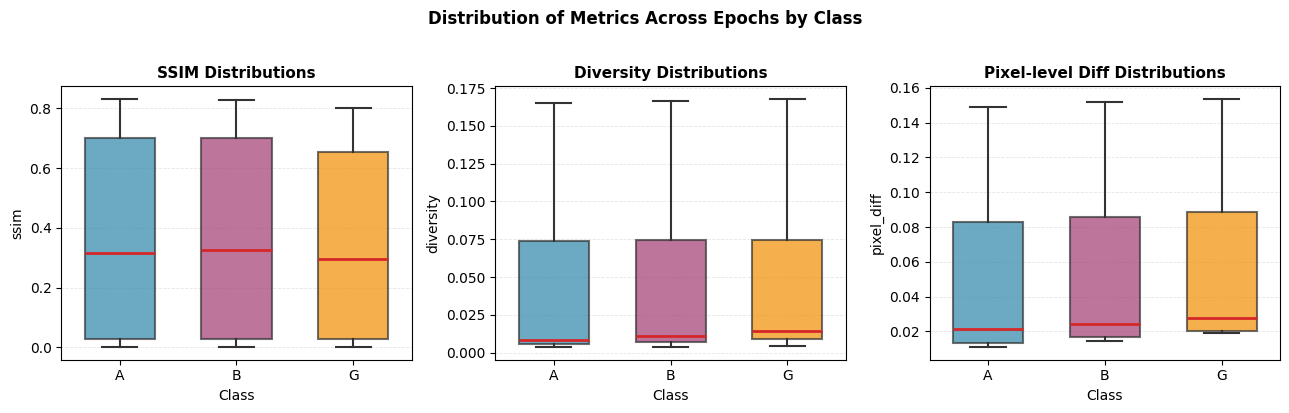

In [10]:
colors = {'A': '#2E86AB', 'B': '#A23B72', 'G': '#F18F01'}
metric_names = {'ssim': 'SSIM Distributions', 'diversity': 'Diversity Distributions', 'pixel_diff': 'Pixel-level Diff Distributions'}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
for ax, metric in zip(axes, metrics):
    data = [df[f"{metric}_{lab}"].dropna().values for lab in labels]
    bp = ax.boxplot(
        data,
        tick_labels=labels,
        widths=0.6,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='#E8F4F8', edgecolor='#333', linewidth=1.5),
        whiskerprops=dict(color='#333', linewidth=1.5),
        capprops=dict(color='#333', linewidth=1.5),
        medianprops=dict(color='#D62728', linewidth=2),
    )
    
    # Color the boxes differently per class
    for patch, lab in zip(bp['boxes'], labels):
        patch.set_facecolor(colors[lab])
        patch.set_alpha(0.7)
    
    ax.set_title(metric_names[metric], fontsize=11, fontweight='bold')
    ax.set_xlabel("Class", fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.3)

plt.suptitle("Distribution of Metrics Across Epochs by Class", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

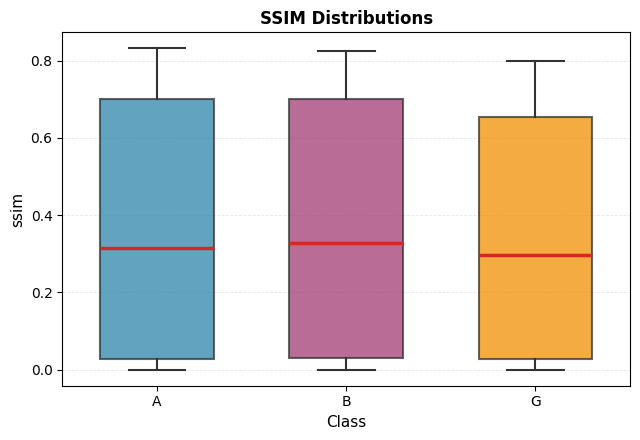

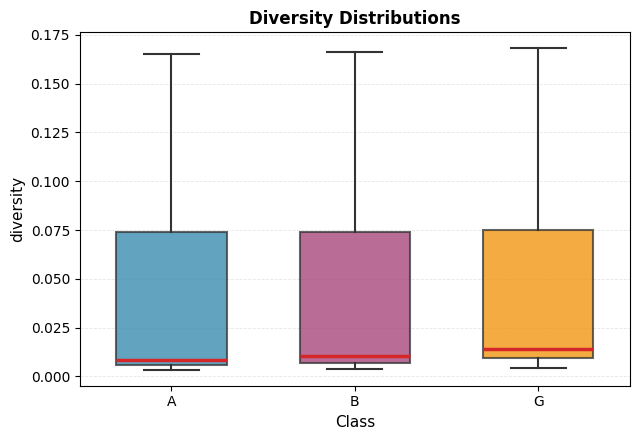

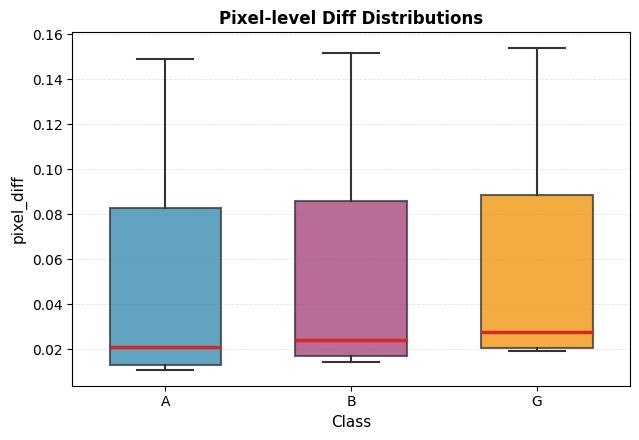

In [11]:
colors = {'A': '#2E86AB', 'B': '#A23B72', 'G': '#F18F01'}
metric_names = {'ssim': 'SSIM Distributions', 'diversity': 'Diversity Distributions', 'pixel_diff': 'Pixel-level Diff Distributions'}

for metric in metrics:
    plt.figure(figsize=(6.5, 4.5))
    data = [df[f"{metric}_{lab}"].dropna().values for lab in labels]
    bp = plt.boxplot(
        data,
        tick_labels=labels,
        widths=0.6,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='#E8F4F8', edgecolor='#333', linewidth=1.5),
        whiskerprops=dict(color='#333', linewidth=1.5),
        capprops=dict(color='#333', linewidth=1.5),
        medianprops=dict(color='#D62728', linewidth=2.5),
    )
    
    # Color the boxes differently per class
    for patch, lab in zip(bp['boxes'], labels):
        patch.set_facecolor(colors[lab])
        patch.set_alpha(0.75)
    
    plt.title(metric_names[metric], fontsize=12, fontweight='bold')
    plt.xlabel("Class", fontsize=11)
    plt.ylabel(metric, fontsize=11)
    plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.3)
    plt.tight_layout()
    plt.show()